<a href="https://colab.research.google.com/github/rudalshan0412-code/Building-an-Artificial-Neural-Network-from-Scratch-using-NumPy/blob/main/%EB%AF%B8%EB%8B%88_%EB%87%8C_%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8_03(%EC%A7%81%EC%A0%91_%EB%A7%8C%EB%93%A0_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EC%B6%94%EA%B0%80_%ED%95%99%EC%8A%B5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 실제로 그림판을 통해 입력한 데이터는 최종 예측 확률인 97%와 차이가 크다고 느껴졌다.
# 따라서, 그림판을 통해 직접 0~9까지 각 30장씩 총 300장의 학습용 데이터와 30장씩 총 300장의 시험 데이터를 만든 이후
# 기존 학습한 모델에서의 시험 데이터에 대한 예측값이 맞을 확률과 학습용 데이터를 추가로 학습한 이후
# 예측값이 맞을 경우를 비교해본다.


# Google Drive에 올린 paint_dataset.zip 공유 링크
# url = "https://drive.google.com/file/d/1VsOfb8O_T_aAClwMN81qNIqQL9SG1ww1/view?usp=sharing"

In [ ]:
# 기존 학습 모델
import numpy as np
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)
x_train = x_train / 255.0
x_test = x_test / 255.0

def one_hot(y, num_classes = 10):

  result = np.zeros((len(y), num_classes))
  result[np.arange(len(y)), y] = 1
  return result

y_train_onehot = one_hot(y_train)
y_test_onehot = one_hot(y_test)

input_size = 784
hidden_size = 128
output_size = 10

np.random.seed(0)
w1 = np.random.randn(input_size, hidden_size) * 0.01

b1 = np.zeros((1, hidden_size))
w2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

def relu(x):

  return np.maximum(0, x)

def relu_derivative(x):

  return (x > 0).astype(float)

def softmax(x):

  x = x - np.max(x, axis = 1, keepdims = True)
  exp_x = np.exp(x)

  return exp_x / np.sum(exp_x, axis = 1, keepdims = True)

def cross_entropy(y_true, y_pred):

  return -np.mean(np.sum(y_true * np.log(y_pred + 1e-7), axis = 1))

def accuracy(y_true, y_pred):

  true_labels = np.argmax(y_true, axis = 1)
  pred_labels = np.argmax(y_pred, axis = 1)

  return np.mean(true_labels == pred_labels)

def forward(x, w1, b1, w2, b2):

  z1 = x @ w1 + b1
  a1 = relu(z1)
  z2 = a1 @ w2 + b2
  y_pred = softmax(z2)

  return z1, a1, z2, y_pred

# 학습

learning_rate = 0.1
epochs = 10
batch_size = 100

for epoch in range(epochs):

  indices = np.random.permutation(len(x_train))
  x_train_shuffled = x_train[indices]
  y_train_shuffled = y_train_onehot[indices]

  for i in range(0, len(x_train), batch_size):

    x_batch = x_train_shuffled[i:i+batch_size]
    y_batch = y_train_shuffled[i:i+batch_size]


    z1, a1, z2, y_pred = forward(x_batch, w1, b1, w2, b2)


    loss = cross_entropy(y_batch, y_pred)


    batch_len = x_batch.shape[0]

    d_z2 = (y_pred - y_batch) / batch_len
    d_w2 = a1.T @ d_z2
    d_b2 = np.sum(d_z2, axis = 0, keepdims = True)

    d_a1 = d_z2 @ w2.T
    d_z1 = d_a1 * relu_derivative(z1)
    d_w1 = x_batch.T @ d_z1
    d_b1 = np.sum(d_z1, axis = 0, keepdims = True)

    # 가중치 업데이트

    w1 -= learning_rate * d_w1
    b1 -= learning_rate * d_b1
    w2 -= learning_rate * d_w2
    b2 -= learning_rate * d_b2

_, _, _, train_pred = forward(x_train, w1, b1, w2, b2)
train_loss = cross_entropy(y_train_onehot, train_pred)
train_acc = accuracy(y_train_onehot, train_pred)

_, _, _, test_pred = forward(x_test, w1, b1, w2, b2)
test_acc = accuracy(y_test_onehot, test_pred)
print(f"Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

# MNIST 데이터를 학습 하였을 때의 가중치

w1_base = w1.copy()
b1_base = b1.copy()
w2_base = w2.copy()
b2_base = b2.copy()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Loss: 0.0822 | Train Acc: 0.9777 | Test Acc: 0.9710


In [ ]:
# 만든 데이터는 아래에 올려두었으니 만들어진 데이터로 확인하고 싶은 경우 다음 코드로 넘어가시면 됩니다.

In [ ]:
# 데이터 만들기(제작자의 드라이브 기준입니다.)
# /content/drive/MyDrive/mini_brain_project/paint_dataset 에 데이터 저장

from google.colab import drive, output
from IPython.display import HTML, display
import base64
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image

# 1. Google Drive 연결
drive.mount('/content/drive')

# 2. Drive가 연결됐는지 확인
if not os.path.ismount("/content/drive"):
    raise RuntimeError("Google Drive가 제대로 연결되지 않았습니다. 저장을 중단합니다.")

# 3. 저장 경로 설정
DATASET_DIR = "/content/drive/MyDrive/mini_brain_project/paint_dataset"

print("Drive 연결 확인:", os.path.ismount("/content/drive"))
print("저장 경로:", DATASET_DIR)
print("저장 경로 존재 여부:", os.path.exists(DATASET_DIR))

# 4. train/test/0~9 폴더 존재 확인
for split in ["train", "test"]:
    for label in range(10):
        folder_path = os.path.join(DATASET_DIR, split, str(label))

        if not os.path.exists(folder_path):
            raise FileNotFoundError(f"폴더가 없습니다: {folder_path}")

print("train/test/0~9 폴더 확인 완료")


def get_next_image_path(split, label):
    folder_path = os.path.join(DATASET_DIR, split, str(label))

    existing_files = glob.glob(os.path.join(folder_path, "*.png"))

    numbers = []

    for file_path in existing_files:
        file_name = os.path.basename(file_path)
        file_name_without_ext = os.path.splitext(file_name)[0]

        try:
            number = int(file_name_without_ext.split("_")[-1])
            numbers.append(number)
        except:
            pass

    if len(numbers) == 0:
        next_number = 1
    else:
        next_number = max(numbers) + 1

    save_path = os.path.join(folder_path, f"{label}_{next_number:03d}.png")

    return save_path


def save_canvas_image(data, split, label):
    image_data = data.split(",")[1]
    image_bytes = base64.b64decode(image_data)

    save_path = get_next_image_path(split, label)

    with open(save_path, "wb") as f:
        f.write(image_bytes)

    current_count = len(glob.glob(os.path.join(DATASET_DIR, split, str(label), "*.png")))

    print(f"저장 완료: {save_path}")
    print(f"현재 {split}/{label} 폴더 이미지 개수: {current_count}장")


output.register_callback("notebook.save_canvas_image", save_canvas_image)

display(HTML("""
<div style="font-family: Arial; margin-bottom: 10px;">
    <label>데이터 종류: </label>
    <select id="splitSelect">
        <option value="train">train</option>
        <option value="test">test</option>
    </select>

    <label style="margin-left: 20px;">숫자 라벨: </label>
    <select id="labelSelect">
        <option value="0">0</option>
        <option value="1">1</option>
        <option value="2">2</option>
        <option value="3">3</option>
        <option value="4">4</option>
        <option value="5">5</option>
        <option value="6">6</option>
        <option value="7">7</option>
        <option value="8">8</option>
        <option value="9">9</option>
    </select>
</div>

<canvas id="canvas" width="280" height="280"
style="border:2px solid black; background:black; touch-action:none;"></canvas>
<br><br>

<button onclick="clearCanvas()">Clear</button>
<button onclick="saveImage()">Save</button>

<script>
const canvas = document.getElementById("canvas");
const ctx = canvas.getContext("2d");

ctx.fillStyle = "black";
ctx.fillRect(0, 0, canvas.width, canvas.height);

ctx.strokeStyle = "white";
ctx.lineWidth = 18;
ctx.lineCap = "round";
ctx.lineJoin = "round";

let drawing = false;

function getPos(e) {
    const rect = canvas.getBoundingClientRect();

    if (e.touches) {
        return {
            x: e.touches[0].clientX - rect.left,
            y: e.touches[0].clientY - rect.top
        };
    } else {
        return {
            x: e.clientX - rect.left,
            y: e.clientY - rect.top
        };
    }
}

function startDraw(e) {
    drawing = true;
    const pos = getPos(e);
    ctx.beginPath();
    ctx.moveTo(pos.x, pos.y);
    e.preventDefault();
}

function draw(e) {
    if (!drawing) return;
    const pos = getPos(e);
    ctx.lineTo(pos.x, pos.y);
    ctx.stroke();
    e.preventDefault();
}

function endDraw(e) {
    drawing = false;
    e.preventDefault();
}

canvas.addEventListener("mousedown", startDraw);
canvas.addEventListener("mousemove", draw);
canvas.addEventListener("mouseup", endDraw);
canvas.addEventListener("mouseleave", endDraw);

canvas.addEventListener("touchstart", startDraw);
canvas.addEventListener("touchmove", draw);
canvas.addEventListener("touchend", endDraw);

function clearCanvas() {
    ctx.fillStyle = "black";
    ctx.fillRect(0, 0, canvas.width, canvas.height);
}

function saveImage() {
    const data = canvas.toDataURL("image/png");
    const split = document.getElementById("splitSelect").value;
    const label = document.getElementById("labelSelect").value;

    google.colab.kernel.invokeFunction(
        "notebook.save_canvas_image",
        [data, split, label],
        {}
    );

    clearCanvas();
}
</script>
"""))

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# 만든 데이터(제작: 한경민(한국외국어대학교)) 가져오기

!pip -q install gdown

import gdown
import zipfile
import os
import glob
from pathlib import Path
import matplotlib.pyplot as plt
from google.colab import drive, output
from IPython.display import HTML, display
import base64
from PIL import Image

# Google Drive에 올린 paint_dataset.zip 공유 링크
url = "https://drive.google.com/file/d/1VsOfb8O_T_aAClwMN81qNIqQL9SG1ww1/view?usp=sharing"

zip_path = "/content/paint_dataset.zip"
extract_dir = "/content"

# zip 파일 다운로드
gdown.download(url=url, output=zip_path, quiet=False, fuzzy=True)

# 압축 해제
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

# 데이터셋 경로
DATASET_DIR = "/content/paint_dataset"

print("DATASET_DIR:", DATASET_DIR)
print("존재 여부:", os.path.exists(DATASET_DIR))

#제대로 데이터 들어왔는지 확인(train 데이터 0~9 각 30장, test 데이터 0~9 각 30장이 존재하여야 정상입니다)

for split in ["train", "test"]:
    print(f"\n[{split}]")

    for label in range(10):
        folder_path = os.path.join(DATASET_DIR, split, str(label))
        image_paths = glob.glob(os.path.join(folder_path, "*.png"))

        print(f"{label}: {len(image_paths)}장")

Downloading...
From: https://drive.google.com/uc?id=1VsOfb8O_T_aAClwMN81qNIqQL9SG1ww1
To: /content/paint_dataset.zip
100%|██████████| 3.83M/3.83M [00:00<00:00, 95.2MB/s]

DATASET_DIR: /content/paint_dataset
존재 여부: True

[train]
0: 30장
1: 30장
2: 30장
3: 30장
4: 30장
5: 30장
6: 30장
7: 30장
8: 30장
9: 30장

[test]
0: 30장
1: 30장
2: 30장
3: 30장
4: 30장
5: 30장
6: 30장
7: 30장
8: 30장
9: 30장


In [ ]:
# 전처리


PAINT_TRAIN_DIR = os.path.join(DATASET_DIR, "train")
PAINT_TEST_DIR = os.path.join(DATASET_DIR, "test")


def preprocess_paint_image(image_path):
    img = Image.open(image_path).convert("L")

    # 그림판 280x280 이미지를 MNIST 입력 크기 28x28로 축소
    img = img.resize((28, 28))

    arr = np.array(img).astype(np.float32)

    # 0~255 범위이면 0~1로 정규화
    # 이미 0~1이면 다시 나누지 않음
    if arr.max() > 1:
        arr = arr / 255.0

    # 기존 NumPy 모델 입력에 맞게 784로 펼치기
    arr = arr.reshape(784)

    return arr

In [ ]:
# 데이터

def load_paint_dataset(dataset_dir):
    x_data = []
    y_data = []

    for label in range(10):
        label_dir = os.path.join(dataset_dir, str(label))
        image_paths = sorted(glob.glob(os.path.join(label_dir, "*.png")))

        for image_path in image_paths:
            img = preprocess_paint_image(image_path)

            x_data.append(img)
            y_data.append(label)

    x_data = np.array(x_data)
    y_data = np.array(y_data)

    return x_data, y_data


x_paint_train, y_paint_train = load_paint_dataset(PAINT_TRAIN_DIR)
x_paint_test, y_paint_test = load_paint_dataset(PAINT_TEST_DIR)

print("x_paint_train:", x_paint_train.shape)
print("y_paint_train:", y_paint_train.shape)
print("x_paint_test:", x_paint_test.shape)
print("y_paint_test:", y_paint_test.shape)

print("x_paint_train min:", x_paint_train.min())
print("x_paint_train max:", x_paint_train.max())
print("x_paint_train mean:", x_paint_train.mean())

x_paint_train: (300, 784)
y_paint_train: (300,)
x_paint_test: (300, 784)
y_paint_test: (300,)
x_paint_train min: 0.0
x_paint_train max: 1.0
x_paint_train mean: 0.10694034


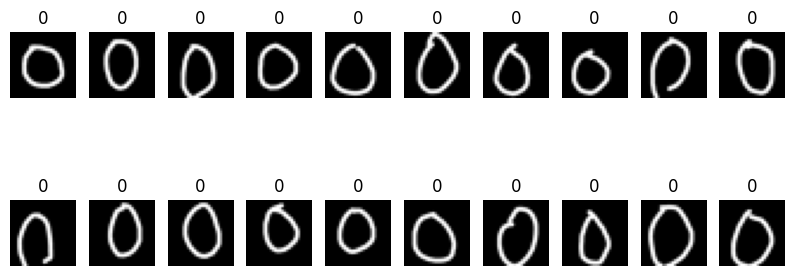

In [ ]:
# 이미지 확인

plt.figure(figsize=(10, 4))

for i in range(20):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_paint_train[i].reshape(28, 28), cmap="gray")
    plt.title(str(y_paint_train[i]))
    plt.axis("off")

plt.show()

In [ ]:
# 라벨링 one-hot 변환

y_paint_train_onehot = one_hot(y_paint_train)
y_paint_test_onehot = one_hot(y_paint_test)

In [ ]:
# 학습 전 그림판 test 정확도 확인

# MNIST 학습 직후 가중치로 복구
w1 = w1_base.copy()
b1 = b1_base.copy()
w2 = w2_base.copy()
b2 = b2_base.copy()

_, _, _, paint_pred_before = forward(x_paint_test, w1, b1, w2, b2)

paint_acc_before = accuracy(y_paint_test_onehot, paint_pred_before)

print(f"추가 학습 전 그림판 test 정확도: {paint_acc_before * 100:.2f}%")

paint_pred_label_before = np.argmax(paint_pred_before, axis=1)
print("추가 학습 전 예측 분포:")
print(np.unique(paint_pred_label_before, return_counts=True))

추가 학습 전 그림판 test 정확도: 63.67%
추가 학습 전 예측 분포:
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([26, 10, 36, 43, 29, 47, 26, 33, 28, 22]))


In [ ]:
# 추가 학습 함수

def finetune_paint_data(
    x_train_data,
    y_train_onehot_data,
    x_test_data,
    y_test_onehot_data,
    w1,
    b1,
    w2,
    b2,
    learning_rate=0.01,
    epochs=50,
    batch_size=16
):
    for epoch in range(epochs):

        indices = np.random.permutation(len(x_train_data))
        x_train_shuffled = x_train_data[indices]
        y_train_shuffled = y_train_onehot_data[indices]

        for i in range(0, len(x_train_data), batch_size):

            x_batch = x_train_shuffled[i:i+batch_size]
            y_batch = y_train_shuffled[i:i+batch_size]

            z1, a1, z2, y_pred = forward(x_batch, w1, b1, w2, b2)

            batch_len = x_batch.shape[0]

            d_z2 = (y_pred - y_batch) / batch_len
            d_w2 = a1.T @ d_z2
            d_b2 = np.sum(d_z2, axis=0, keepdims=True)

            d_a1 = d_z2 @ w2.T
            d_z1 = d_a1 * relu_derivative(z1)
            d_w1 = x_batch.T @ d_z1
            d_b1 = np.sum(d_z1, axis=0, keepdims=True)

            w1 -= learning_rate * d_w1
            b1 -= learning_rate * d_b1
            w2 -= learning_rate * d_w2
            b2 -= learning_rate * d_b2

        _, _, _, train_pred = forward(x_train_data, w1, b1, w2, b2)
        train_loss = cross_entropy(y_train_onehot_data, train_pred)
        train_acc = accuracy(y_train_onehot_data, train_pred)

        _, _, _, test_pred = forward(x_test_data, w1, b1, w2, b2)
        test_acc = accuracy(y_test_onehot_data, test_pred)
        if epoch % 10 == 0:
          print(
              f"Epoch {epoch+1:03d} | "
              f"Loss: {train_loss:.4f} | "
              f"Paint Train Acc: {train_acc * 100:.2f}% | "
              f"Paint Test Acc: {test_acc * 100:.2f}%"
          )
    print(f"Final \nLoss: {train_loss:.4f} \nPaint Train Acc: {train_acc * 100:.2f}% \nPaint Test Acc: {test_acc * 100:.2f}% ")
    return w1, b1, w2, b2

In [ ]:
# 추가 학습

w1 = w1_base.copy()
b1 = b1_base.copy()
w2 = w2_base.copy()
b2 = b2_base.copy()

w1, b1, w2, b2 = finetune_paint_data(
    x_paint_train,
    y_paint_train_onehot,
    x_paint_test,
    y_paint_test_onehot,
    w1,
    b1,
    w2,
    b2,
    learning_rate=0.01,
    epochs=50,
    batch_size=16
)

Epoch 001 | Loss: 1.3526 | Paint Train Acc: 62.33% | Paint Test Acc: 71.00%
Epoch 011 | Loss: 0.3290 | Paint Train Acc: 92.00% | Paint Test Acc: 81.67%
Epoch 021 | Loss: 0.1767 | Paint Train Acc: 96.67% | Paint Test Acc: 85.00%
Epoch 031 | Loss: 0.1106 | Paint Train Acc: 98.67% | Paint Test Acc: 86.33%
Epoch 041 | Loss: 0.0761 | Paint Train Acc: 99.67% | Paint Test Acc: 88.33%
Final 
Loss: 0.0586 
Paint Train Acc: 100.00% 
Paint Test Acc: 88.67% 


In [ ]:
# 정확도 확인

_, _, _, paint_pred_after = forward(x_paint_test, w1, b1, w2, b2)

paint_acc_after = accuracy(y_paint_test_onehot, paint_pred_after)

print(f"추가 학습 전 그림판 test 정확도: {paint_acc_before * 100:.2f}%")
print(f"추가 학습 후 그림판 test 정확도: {paint_acc_after * 100:.2f}%")
print(f"정확도 향상: {(paint_acc_after - paint_acc_before) * 100:.2f}%p")

paint_pred_label_after = np.argmax(paint_pred_after, axis=1)
print("추가 학습 후 예측 분포:")
print(np.unique(paint_pred_label_after, return_counts=True))

추가 학습 전 그림판 test 정확도: 63.67%
추가 학습 후 그림판 test 정확도: 88.67%
정확도 향상: 25.00%p
추가 학습 후 예측 분포:
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([33, 31, 33, 25, 32, 26, 35, 32, 28, 25]))


In [ ]:
# 학습이 성공적임을 알 수 있다

In [ ]:
# 직접 넣어보기

# 그림판 코드

from google.colab import output
from IPython.display import HTML, display
import base64

def save_canvas_image(data):
    image_data = data.split(",")[1]
    image_bytes = base64.b64decode(image_data)

    with open("/content/my_number.png", "wb") as f:
        f.write(image_bytes)

    print("저장 완료: /content/my_number.png")

output.register_callback("notebook.save_canvas_image", save_canvas_image)

display(HTML("""
<canvas id="canvas" width="280" height="280"
style="border:2px solid black; background:black; touch-action:none;"></canvas>
<br>
<button onclick="clearCanvas()">Clear</button>
<button onclick="saveImage()">Save</button>

<script>
const canvas = document.getElementById("canvas");
const ctx = canvas.getContext("2d");

ctx.fillStyle = "black";
ctx.fillRect(0, 0, canvas.width, canvas.height);

ctx.strokeStyle = "white";
ctx.lineWidth = 18;
ctx.lineCap = "round";
ctx.lineJoin = "round";

let drawing = false;

function getPos(e) {
    const rect = canvas.getBoundingClientRect();

    if (e.touches) {
        return {
            x: e.touches[0].clientX - rect.left,
            y: e.touches[0].clientY - rect.top
        };
    } else {
        return {
            x: e.clientX - rect.left,
            y: e.clientY - rect.top
        };
    }
}

function startDraw(e) {
    drawing = true;
    const pos = getPos(e);
    ctx.beginPath();
    ctx.moveTo(pos.x, pos.y);
    e.preventDefault();
}

function draw(e) {
    if (!drawing) return;
    const pos = getPos(e);
    ctx.lineTo(pos.x, pos.y);
    ctx.stroke();
    e.preventDefault();
}

function endDraw(e) {
    drawing = false;
    e.preventDefault();
}

canvas.addEventListener("mousedown", startDraw);
canvas.addEventListener("mousemove", draw);
canvas.addEventListener("mouseup", endDraw);
canvas.addEventListener("mouseleave", endDraw);

canvas.addEventListener("touchstart", startDraw);
canvas.addEventListener("touchmove", draw);
canvas.addEventListener("touchend", endDraw);

function clearCanvas() {
    ctx.fillStyle = "black";
    ctx.fillRect(0, 0, canvas.width, canvas.height);
}

function saveImage() {
    const data = canvas.toDataURL("image/png");
    google.colab.kernel.invokeFunction("notebook.save_canvas_image", [data], {});
}
</script>
"""))

저장 완료: /content/my_number.png
저장 완료: /content/my_number.png


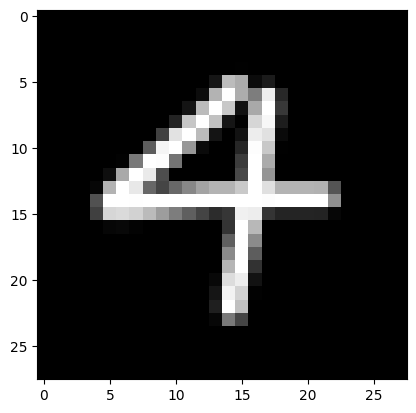

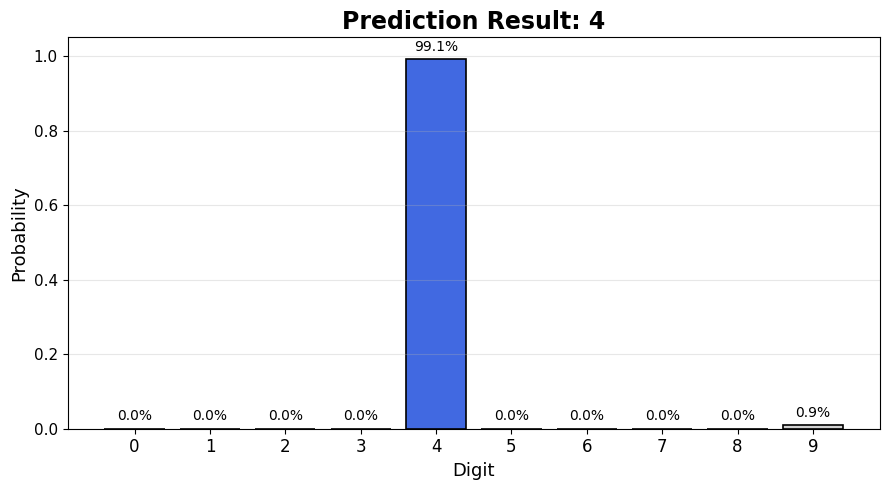

예측 숫자: 4


In [ ]:
# 결과 확인하기
from PIL import Image

# 예측결과 시각화 함수def plot_prediction(pred):

def plot_prediction(pred):
  probs = pred[0]
  predicted_digit = np.argmax(probs)

  digits = np.arange(10)

  # 예측한 숫자만 강조
  colors = ["lightgray"] * 10
  colors[predicted_digit] = "royalblue"

  plt.figure(figsize=(9, 5))

  bars = plt.bar(digits, probs, color=colors, edgecolor="black", linewidth=1.2)

  # 막대 위에 확률 표시
  for bar, prob in zip(bars, probs):
      height = bar.get_height()
      plt.text(
          bar.get_x() + bar.get_width() / 2,
          height + 0.015,
          f"{prob*100:.1f}%",
          ha="center",
          va="bottom",
          fontsize=10
      )

  plt.xticks(digits, fontsize=12)
  plt.yticks(fontsize=11)
  plt.ylim(0, 1.05)

  plt.xlabel("Digit", fontsize=13)
  plt.ylabel("Probability", fontsize=13)
  plt.title(f"Prediction Result: {predicted_digit}", fontsize=17, fontweight="bold")

  plt.grid(axis="y", alpha=0.3)
  plt.tight_layout()
  plt.show()

img = Image.open("/content/my_number.png").convert("L")
img = img.resize((28, 28))

img_array = np.array(img) / 255.0

plt.imshow(img_array, cmap="gray")

img_input = img_array.reshape(1, 784)

_, _, _, pred = forward(img_input, w1, b1, w2, b2)

plt.imshow(img_array, cmap='gray')
plt.show()

plot_prediction(pred)
print("예측 숫자:", np.argmax(pred))